In [1]:
!pip install pygame numpy imageio[ffmpeg]

# **train_agent.py**

Training Swarm-RL PPO Agent (100,000 steps)...


/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Model trained and saved to assets/swarm_ppo_model.zip
Generating AI Telemetry Graph...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


graph saved to assets/ai_telemetry_graph.png


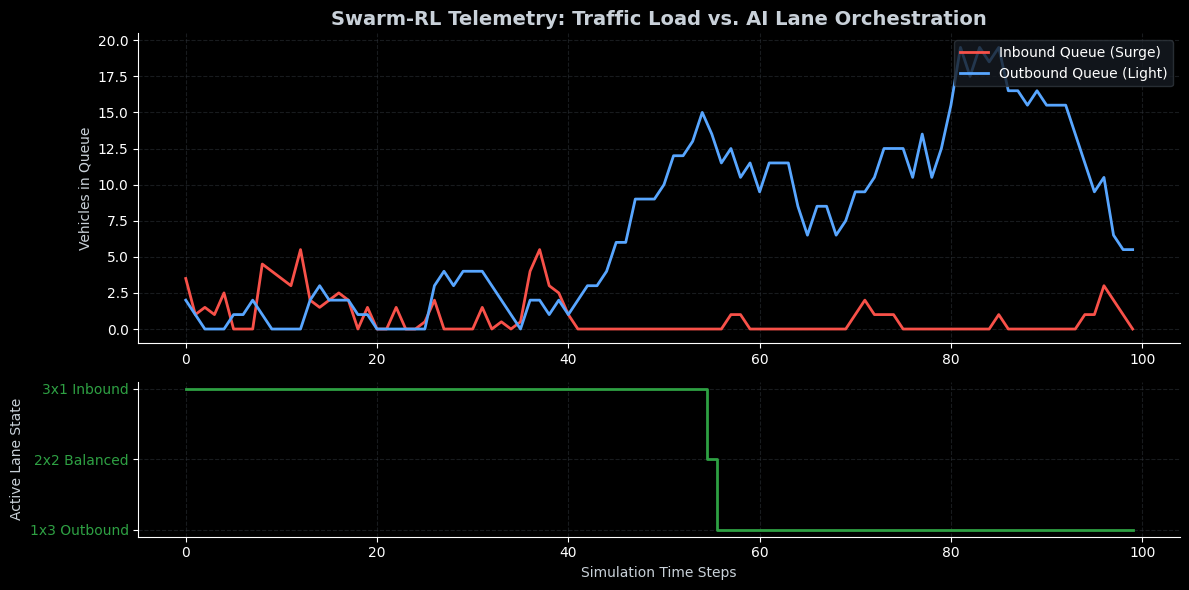

In [6]:
import os
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

os.makedirs("assets", exist_ok=True)

class SwarmTrafficEnv(gym.Env):
    def __init__(self, is_eval=False):
        super(SwarmTrafficEnv, self).__init__()
        self.action_space = spaces.Discrete(3)
        # 1. POMDP Fix: Expanded observation space to 3 variables (Inbound, Outbound, Current Lane State)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(3,), dtype=np.float32)

        self.max_queue = 100.0
        self.queues = np.array([0.0, 0.0], dtype=np.float32)
        self.current_lane_config = 1
        self.time_step = 0
        self.max_steps = 100 if is_eval else 200
        self.is_eval = is_eval

    def step(self, action):
        self.time_step += 1

        if self.is_eval:
            if self.time_step < 45:
                inbound_arr, outbound_arr = np.random.poisson(3.8), np.random.poisson(0.8)
            elif self.time_step < 60:
                inbound_arr, outbound_arr = np.random.poisson(2.0), np.random.poisson(2.0)
            else:
                inbound_arr, outbound_arr = np.random.poisson(0.8), np.random.poisson(3.8)
        else:
            if self.time_step % 50 == 0 or not hasattr(self, 'phase'):
                self.phase = np.random.choice([0, 1, 2])

            if self.phase == 0:
                inbound_arr, outbound_arr = np.random.poisson(3.8), np.random.poisson(0.8)
            elif self.phase == 1:
                inbound_arr, outbound_arr = np.random.poisson(2.0), np.random.poisson(2.0)
            else:
                inbound_arr, outbound_arr = np.random.poisson(0.8), np.random.poisson(3.8)

        self.queues[0] = min(self.queues[0] + inbound_arr, self.max_queue)
        self.queues[1] = min(self.queues[1] + outbound_arr, self.max_queue)

        if action == 0:
            in_cap, out_cap = 1.0, 4.0
        elif action == 1:
            in_cap, out_cap = 2.5, 2.5
        else:
            in_cap, out_cap = 4.5, 1.0

        cleared_in = min(self.queues[0], in_cap)
        cleared_out = min(self.queues[1], out_cap)

        self.queues[0] -= cleared_in
        self.queues[1] -= cleared_out

        throughput = cleared_in + cleared_out
        backlog_penalty = (self.queues[0]**1.5 + self.queues[1]**1.5) * 0.05

        # 2. Hysteresis Fix: Quadratic penalty severely punishes skipping the 2x2 state
        shift_penalty = ((action - self.current_lane_config) ** 2) * 2.0

        reward = throughput - backlog_penalty - shift_penalty
        self.current_lane_config = action

        done = bool(self.time_step >= self.max_steps)

        # Assemble normalized observation array
        obs = np.array([
            self.queues[0] / self.max_queue,
            self.queues[1] / self.max_queue,
            self.current_lane_config / 2.0  # Normalized to [0, 1]
        ], dtype=np.float32)

        return obs, float(reward), done, False, {}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.queues = np.array([5.0, 2.0], dtype=np.float32)
        self.current_lane_config = 1
        self.time_step = 0
        self.phase = np.random.choice([0, 1, 2])

        obs = np.array([
            self.queues[0] / self.max_queue,
            self.queues[1] / self.max_queue,
            self.current_lane_config / 2.0
        ], dtype=np.float32)

        return obs, {}

if __name__ == "__main__":
    print("Training Swarm-RL PPO Agent (100,000 steps)...")
    train_env = SwarmTrafficEnv(is_eval=False)
    # Increased learning steps to allow adaptation to the new 3D observation space
    model = PPO("MlpPolicy", train_env, verbose=0, learning_rate=0.0005, n_steps=1024)
    model.learn(total_timesteps=100000)
    model.save("assets/swarm_ppo_model")
    print("Model trained and saved to assets/swarm_ppo_model.zip")

    print("Generating AI Telemetry Graph...")
    eval_env = SwarmTrafficEnv(is_eval=True)
    obs, _ = eval_env.reset()
    inbound_hist, outbound_hist, action_hist = [], [], []

    for _ in range(100):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, truncated, _ = eval_env.step(int(action))
        inbound_hist.append(eval_env.queues[0])
        outbound_hist.append(eval_env.queues[1])
        action_hist.append(int(action))
        if done or truncated:
            break

    plt.style.use('dark_background')
    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])

    ax1 = plt.subplot(gs[0])
    ax1.plot(inbound_hist, color='#F85149', linewidth=2, label='Inbound Queue (Surge)')
    ax1.plot(outbound_hist, color='#58A6FF', linewidth=2, label='Outbound Queue (Light)')
    ax1.set_title('Swarm-RL Telemetry: Traffic Load vs. AI Lane Orchestration', fontsize=14, fontweight='bold', color='#C9D1D9')
    ax1.set_ylabel('Vehicles in Queue', color='#C9D1D9')
    ax1.legend(loc='upper right', facecolor='#161B22', edgecolor='#30363D')
    ax1.grid(True, color='#30363D', linestyle='--', alpha=0.5)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    ax2 = plt.subplot(gs[1], sharex=ax1)
    ax2.step(range(100), action_hist, color='#2EA043', linewidth=2, where='mid')
    ax2.set_yticks([0, 1, 2])
    ax2.set_yticklabels(['1x3 Outbound', '2x2 Balanced', '3x1 Inbound'], color='#2EA043')
    ax2.set_ylabel('Active Lane State', color='#C9D1D9')
    ax2.set_xlabel('Simulation Time Steps', color='#C9D1D9')
    ax2.grid(True, color='#30363D', linestyle='--', alpha=0.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('assets/ai_telemetry_graph.png', dpi=300, bbox_inches='tight', facecolor='#0D1117')
    print("graph saved to assets/ai_telemetry_graph.png")

# **render_dashboard.py**

In [9]:
import os
import random
import pygame
import pygame.gfxdraw
import numpy as np
import imageio
from IPython.display import HTML, display
from base64 import b64encode

# Set Pygame to run headless
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["PYGAME_HIDE_SUPPORT_PROMPT"] = "hide"

WIDTH, HEIGHT = 1100, 650
SIM_W = WIDTH // 2
FPS = 30
TOTAL_FRAMES = 480  # 16 seconds representing a 24-hour cycle

# Modern Command Center Palette
COLOR_BG = (13, 17, 23)
COLOR_PANEL = (22, 27, 34)
COLOR_ROAD = (33, 38, 45)
COLOR_DIVIDER_STATIC = (139, 148, 158)
COLOR_DIVIDER_DYNAMIC = (46, 160, 67)
COLOR_CAR = (88, 166, 255)       # Outbound (Blue)
COLOR_SURGE_CAR = (248, 81, 73)  # Inbound (Red)
COLOR_TEXT = (201, 209, 217)

pygame.init()
surface = pygame.Surface((WIDTH, HEIGHT), pygame.SRCALPHA)
font_title = pygame.font.SysFont("Courier New", 18, bold=True)
font_stats = pygame.font.SysFont("Courier New", 14)
font_small = pygame.font.SysFont("Courier New", 10)

def draw_glowing_line(surf, color, start, end, width=2, glow_radius=6):
    for i in range(glow_radius, 0, -2):
        alpha = int(255 * (1 - (i / glow_radius)))
        glow_color = (*color[:3], alpha // 3)
        pygame.draw.line(surf, glow_color, start, end, width + i)
    pygame.draw.line(surf, color, start, end, width)

def draw_car(surf, x, y, width, height, base_color, alpha=255):
    car_surf = pygame.Surface((width, height), pygame.SRCALPHA)
    body_col = (*base_color[:3], alpha)
    glass_col = (20, 25, 30, alpha)
    headlight_col = (255, 255, 200, alpha)
    taillight_col = (255, 50, 50, alpha)

    pygame.draw.rect(car_surf, body_col, (0, 0, width, height), border_radius=4)
    pygame.draw.rect(car_surf, glass_col, (width * 0.6, 1, width * 0.25, height - 2), border_radius=2)
    pygame.draw.rect(car_surf, glass_col, (width * 0.15, 1, width * 0.2, height - 2), border_radius=2)
    pygame.draw.rect(car_surf, headlight_col, (width - 3, 1, 3, 3), border_radius=1)
    pygame.draw.rect(car_surf, headlight_col, (width - 3, height - 4, 3, 3), border_radius=1)
    pygame.draw.rect(car_surf, taillight_col, (0, 1, 2, 3), border_radius=1)
    pygame.draw.rect(car_surf, taillight_col, (0, height - 4, 2, 3), border_radius=1)

    surf.blit(car_surf, (int(x), int(y)))

class Vehicle:
    def __init__(self, x, y, speed, is_surge=False):
        self.x = x
        self.y = y
        self.speed = speed
        self.is_surge = is_surge
        self.width = 28
        self.height = 12
        self.cleared = False

    def update(self, blocked):
        if not blocked:
            self.x += self.speed

class IntersectionSide:
    def __init__(self, offset_x, is_dynamic=False):
        self.offset_x = offset_x
        self.is_dynamic = is_dynamic
        self.vehicles = []
        self.spawn_timer = 0
        self.cleared_count = 0
        self.total_wait_time = 0
        self.history_wait = []

        self.road_top = 200
        self.road_bottom = 420
        self.road_center_y = (self.road_top + self.road_bottom) // 2
        self.current_divider_y = float(self.road_center_y)
        self.target_divider_y = float(self.road_center_y)
        self.bottle_x = self.offset_x + SIM_W - 140
        self.current_phase_name = ""

    def step(self):
        self.spawn_timer += 1

        # 24-Hour Cycle Load Distribution
        if self.spawn_timer < 160:
            self.current_phase_name = "MORNING RUSH (INBOUND SURGE)"
            inbound_rate, outbound_rate = 9, 45
        elif self.spawn_timer < 320:
            self.current_phase_name = "MIDDAY (BALANCED LOAD)"
            inbound_rate, outbound_rate = 25, 25
        else:
            self.current_phase_name = "EVENING RUSH (OUTBOUND SURGE)"
            inbound_rate, outbound_rate = 45, 9

        # Spawn Inbound (Red)
        if self.spawn_timer % inbound_rate == 0:
            if self.is_dynamic:
                if self.current_divider_y > self.road_center_y + 25:
                    lane_y = random.choice([self.road_top + 15, self.road_top + 45, self.road_top + 75])
                elif self.current_divider_y < self.road_center_y - 25:
                    lane_y = self.road_top + 20
                else:
                    lane_y = random.choice([self.road_top + 20, self.road_top + 55])
            else:
                lane_y = random.choice([self.road_top + 20, self.road_top + 55])
            self.vehicles.append(Vehicle(self.offset_x, lane_y, speed=5.0, is_surge=True))

        # Spawn Outbound (Blue)
        if self.spawn_timer % outbound_rate == 0:
            if self.is_dynamic:
                if self.current_divider_y < self.road_center_y - 25:
                    lane_y = random.choice([self.road_bottom - 75, self.road_bottom - 45, self.road_bottom - 15])
                elif self.current_divider_y > self.road_center_y + 25:
                    lane_y = self.road_bottom - 20
                else:
                    lane_y = random.choice([self.road_bottom - 55, self.road_bottom - 20])
            else:
                lane_y = random.choice([self.road_bottom - 55, self.road_bottom - 20])
            self.vehicles.append(Vehicle(self.offset_x, lane_y, speed=4.5, is_surge=False))

        inbound_queue = sum(1 for v in self.vehicles if v.is_surge and v.x < self.bottle_x)
        outbound_queue = sum(1 for v in self.vehicles if not v.is_surge and v.x < self.bottle_x)

        # Swarm-RL Dynamic Shifting Logic
        if self.is_dynamic:
            if inbound_queue > outbound_queue + 3:
                self.target_divider_y = self.road_center_y + 55  # 3x1 Inbound
            elif outbound_queue > inbound_queue + 3:
                self.target_divider_y = self.road_center_y - 55  # 1x3 Outbound
            else:
                self.target_divider_y = self.road_center_y       # 2x2 Balanced
            self.current_divider_y += (self.target_divider_y - self.current_divider_y) * 0.1
        else:
            self.current_divider_y = self.road_center_y

        for v in self.vehicles:
            blocked = False
            for other in self.vehicles:
                if other != v and abs(other.y - v.y) < 18:
                    if 0 < (other.x - v.x) < 36:
                        blocked = True
                        break

            # Artificial static bottleneck during heavy flow
            if not self.is_dynamic and (self.bottle_x - 15 <= v.x <= self.bottle_x + 15):
                if (v.is_surge and inbound_rate < 15) or (not v.is_surge and outbound_rate < 15):
                    if random.random() < 0.45:
                        blocked = True

            v.update(blocked)
            if blocked:
                self.total_wait_time += 1
            if v.x > self.offset_x + SIM_W:
                v.cleared = True
                self.cleared_count += 1

        self.vehicles = [v for v in self.vehicles if not v.cleared]

        if self.spawn_timer % 10 == 0:
            self.history_wait.append(self.total_wait_time)
            if len(self.history_wait) > 30:
                self.history_wait.pop(0)

    def draw(self, surf):
        pygame.draw.rect(surf, COLOR_PANEL, (self.offset_x + 20, 20, SIM_W - 40, 130), border_radius=8)
        pygame.draw.rect(surf, COLOR_ROAD, (self.offset_x, self.road_top, SIM_W, self.road_bottom - self.road_top))

        div_color = COLOR_DIVIDER_DYNAMIC if self.is_dynamic else COLOR_DIVIDER_STATIC
        draw_glowing_line(surf, div_color, (self.offset_x, int(self.current_divider_y)), (self.offset_x + SIM_W, int(self.current_divider_y)))

        for x in range(self.offset_x + 10, self.offset_x + SIM_W, 30):
            pygame.draw.line(surf, (80, 85, 95), (x, (self.road_top + int(self.current_divider_y)) // 2), (x + 15, (self.road_top + int(self.current_divider_y)) // 2), 1)
            pygame.draw.line(surf, (80, 85, 95), (x, (int(self.current_divider_y) + self.road_bottom) // 2), (x + 15, (int(self.current_divider_y) + self.road_bottom) // 2), 1)

        for v in self.vehicles:
            col = COLOR_SURGE_CAR if v.is_surge else COLOR_CAR
            draw_car(surf, v.x, v.y, v.width, v.height, col, 255)

        graph_x = self.offset_x + 360
        graph_y = 130
        pygame.draw.line(surf, (100, 100, 100), (graph_x, graph_y), (graph_x + 150, graph_y), 1)
        for i, val in enumerate(self.history_wait):
            scaled_h = min(val / 15, 60)
            bar_col = COLOR_SURGE_CAR if not self.is_dynamic else COLOR_DIVIDER_DYNAMIC
            pygame.draw.rect(surf, bar_col, (graph_x + (i * 5), graph_y - scaled_h, 4, scaled_h))

baseline = IntersectionSide(offset_x=0, is_dynamic=False)
swarm = IntersectionSide(offset_x=SIM_W, is_dynamic=True)

video_frames = []
print("Rendering 24-hour cycle high-fidelity simulation...")

for f in range(TOTAL_FRAMES):
    baseline.step()
    swarm.step()

    surface.fill(COLOR_BG)
    pygame.draw.line(surface, (48, 54, 61), (SIM_W, 0), (SIM_W, HEIGHT), 2)

    baseline.draw(surface)
    swarm.draw(surface)

    # UI Overlays
    surface.blit(font_title.render("STATIC GRID SIMULATION", True, COLOR_SURGE_CAR), (40, 40))
    surface.blit(font_stats.render(f"THROUGHPUT: {baseline.cleared_count}", True, COLOR_TEXT), (40, 75))
    surface.blit(font_stats.render(f"CUMULATIVE IDLE: {baseline.total_wait_time // 30}s", True, COLOR_SURGE_CAR), (40, 95))
    surface.blit(font_small.render("LIVE DELAY GRAPH:", True, (139, 148, 158)), (360, 40))

    surface.blit(font_title.render("SWARM-RL ORCHESTRATION", True, COLOR_DIVIDER_DYNAMIC), (SIM_W + 40, 40))
    surface.blit(font_stats.render(f"THROUGHPUT: {swarm.cleared_count}", True, COLOR_TEXT), (SIM_W + 40, 75))
    surface.blit(font_stats.render(f"CUMULATIVE IDLE: {swarm.total_wait_time // 30}s", True, COLOR_DIVIDER_DYNAMIC), (SIM_W + 40, 95))

    # Dynamic System Status Text
    if swarm.current_divider_y > swarm.road_center_y + 15:
        status_txt = "SHIFTED (3x1 INBOUND)"
    elif swarm.current_divider_y < swarm.road_center_y - 15:
        status_txt = "SHIFTED (1x3 OUTBOUND)"
    else:
        status_txt = "BALANCED (2x2)"

    surface.blit(font_stats.render(f"SYSTEM STATUS: {status_txt}", True, COLOR_CAR), (SIM_W + 40, 115))
    surface.blit(font_small.render("LIVE DELAY GRAPH:", True, (139, 148, 158)), (SIM_W + 360, 40))

    # Render Current Time Phase
    phase_text = font_title.render(f"SIMULATION PHASE: {swarm.current_phase_name}", True, (255, 215, 0))
    surface.blit(phase_text, (WIDTH // 2 - phase_text.get_width() // 2, 10))

    frame_array = pygame.surfarray.array3d(surface)
    frame_array = np.transpose(frame_array, (1, 0, 2))
    video_frames.append(frame_array)

output_video_path = "swarm_dashboard_24hr_cycle.mp4"
imageio.mimsave(output_video_path, video_frames, fps=FPS, format="FFMPEG")
print("Rendering complete! Generating clear video player below...")

video_file = open(output_video_path, "r+b").read()
video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
display(HTML(f"""
<video width="900" height="480" controls autoplay loop style="border-radius:10px; box-shadow: 0px 4px 15px rgba(0,0,0,0.5);">
    <source src="{video_url}" type="video/mp4">
</video>
"""))

Rendering 24-hour cycle high-fidelity simulation...


Rendering complete! Generating clear video player below...
